# Week 5 — Covariance, Correlation and Responsible Association

This notebook accompanies the lecture on **covariance, correlation and variable association** using the **Ames Housing dataset**.

Learning goals:
- Understand covariance and Pearson correlation
- Identify when Pearson correlation is misleading
- Use Spearman correlation when appropriate
- Explore associations respecting variable types
- Identify potential multicollinearity between predictors

Dataset: Ames Housing
Unit of analysis: individual house sale
Target variable: `SalePrice`


## 1. Setup

Import required libraries.

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_style("whitegrid")

## 2. Load the dataset

Download the dataset from Kaggle and place the CSV in the working directory.

Example filename:
`ames_housing.csv`

In [4]:

import pandas as pd

df = pd.read_csv('./data/raw/AmesHousing.csv')

df.head()

,Order,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
0,1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
1,2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
2,3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
3,4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
4,5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900


## 3. Quick structural overview

Before studying relationships, we review the dataset structure.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2930 entries, 0 to 2929
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order            2930 non-null   int64  
 1   PID              2930 non-null   int64  
 2   MS SubClass      2930 non-null   int64  
 3   MS Zoning        2930 non-null   str    
 4   Lot Frontage     2440 non-null   float64
 5   Lot Area         2930 non-null   int64  
 6   Street           2930 non-null   str    
 7   Alley            198 non-null    str    
 8   Lot Shape        2930 non-null   str    
 9   Land Contour     2930 non-null   str    
 10  Utilities        2930 non-null   str    
 11  Lot Config       2930 non-null   str    
 12  Land Slope       2930 non-null   str    
 13  Neighborhood     2930 non-null   str    
 14  Condition 1      2930 non-null   str    
 15  Condition 2      2930 non-null   str    
 16  Bldg Type        2930 non-null   str    
 17  House Style      2930 non

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Order,2930.0,1.465500e+03,8.459625e+02,1.0,7.332500e+02,1465.5,2.197750e+03,2.930000e+03
PID,2930.0,7.144645e+08,1.887308e+08,526301100.0,5.284770e+08,535453620.0,9.071811e+08,1.007100e+09
MS SubClass,2930.0,5.738737e+01,4.263802e+01,20.0,2.000000e+01,50.0,7.000000e+01,1.900000e+02
Lot Frontage,2440.0,6.922459e+01,2.336533e+01,21.0,5.800000e+01,68.0,8.000000e+01,3.130000e+02
Lot Area,2930.0,1.014792e+04,7.880018e+03,1300.0,7.440250e+03,9436.5,1.155525e+04,2.152450e+05
Overall Qual,2930.0,6.094881e+00,1.411026e+00,1.0,5.000000e+00,6.0,7.000000e+00,1.000000e+01
Overall Cond,2930.0,5.563140e+00,1.111537e+00,1.0,5.000000e+00,5.0,6.000000e+00,9.000000e+00
Year Built,2930.0,1.971356e+03,3.024536e+01,1872.0,1.954000e+03,1973.0,2.001000e+03,2.010000e+03
Year Remod/Add,2930.0,1.984267e+03,2.086029e+01,1950.0,1.965000e+03,1993.0,2.004000e+03,2.010000e+03
Mas Vnr Area,2907.0,1.018968e+02,1.791126e+02,0.0,0.000000e+00,0.0,1.640000e+02,1.600000e+03


## 4. Target distribution

We start by inspecting the target variable: **SalePrice**.

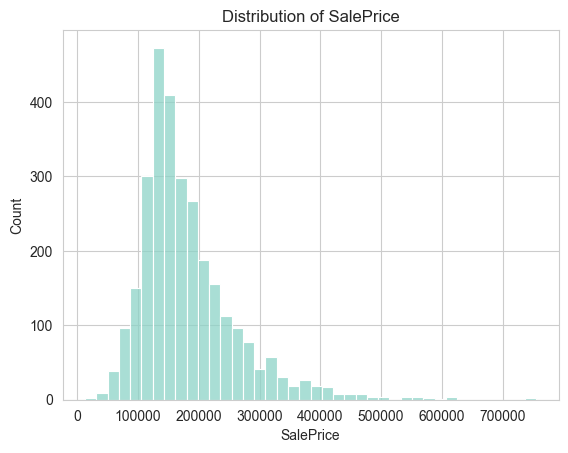

In [58]:
plt.figure()
sns.histplot(df['SalePrice'], bins=40)
plt.title("Distribution of SalePrice")
plt.show()

# 5. Covariance

Covariance measures how two variables **vary together**.

Definition:

Cov(X,Y) = E[(X − μx)(Y − μy)]

Example: covariance between **living area** and **sale price**.

In [59]:
cov_value = df[['Gr Liv Area','SalePrice']].cov()
cov_value

,Gr Liv Area,SalePrice
Gr Liv Area,2.555392e+05,2.854220e+07
SalePrice,2.854220e+07,6.381884e+09


Covariance is difficult to interpret because it depends on **units**.

This motivates **correlation**, a normalized measure.

# 6. Pearson Correlation

Pearson correlation measures **linear relationships**.

Range: -1 to 1

In [60]:
corr = df.corr(numeric_only=True)
corr.head()

,Order,PID,MS SubClass,Lot Frontage,Lot Area,Overall Qual,Overall Cond,Year Built,Year Remod/Add,Mas Vnr Area,...,Enclosed Porch,3Ssn Porch,Screen Porch,Pool Area,Misc Val,Mo Sold,Yr Sold,SalePrice,Neighborhood_encoded,Neighborhood_rank
Order,1.000000,0.173593,0.011797,-0.007034,0.031354,-0.048500,-0.011054,-0.052319,-0.075566,-0.030907,...,0.027908,-0.024975,0.004307,0.052518,-0.006083,0.133365,-0.975993,-0.031408,-0.092748,-0.092748
PID,0.173593,1.000000,-0.001281,-0.096918,0.034868,-0.263147,0.104451,-0.343388,-0.157111,-0.229283,...,0.162519,-0.024894,-0.025735,-0.002845,-0.008260,-0.050455,0.009579,-0.246521,-0.326915,-0.326915
MS SubClass,0.011797,-0.001281,1.000000,-0.420135,-0.204613,0.039419,-0.067349,0.036579,0.043397,0.002730,...,-0.022866,-0.037956,-0.050614,-0.003434,-0.029254,0.000350,-0.017905,-0.085092,-0.004542,-0.004542
Lot Frontage,-0.007034,-0.096918,-0.420135,1.000000,0.491313,0.212042,-0.074448,0.121562,0.091712,0.222407,...,0.012758,0.028564,0.076666,0.173947,0.044476,0.011085,-0.007547,0.357318,0.120140,0.120140
Lot Area,0.031354,0.034868,-0.204613,0.491313,1.000000,0.097188,-0.034759,0.023258,0.021682,0.126830,...,0.021868,0.016243,0.055044,0.093775,0.069188,0.003859,-0.023085,0.266549,0.035629,0.035629


### Correlation with target variable

In [61]:
corr_target = corr['SalePrice'].sort_values(ascending=False)
corr_target.head(15)

SalePrice         1.000000
Overall Qual      0.799262
Gr Liv Area       0.706780
Garage Cars       0.647877
Garage Area       0.640401
Total Bsmt SF     0.632280
1st Flr SF        0.621676
Year Built        0.558426
Full Bath         0.545604
Year Remod/Add    0.532974
Garage Yr Blt     0.526965
Mas Vnr Area      0.508285
TotRms AbvGrd     0.495474
Fireplaces        0.474558
BsmtFin SF 1      0.432914
Name: SalePrice, dtype: float64

## 7. Visualizing correlations

Correlation matrices help detect relationships and multicollinearity.

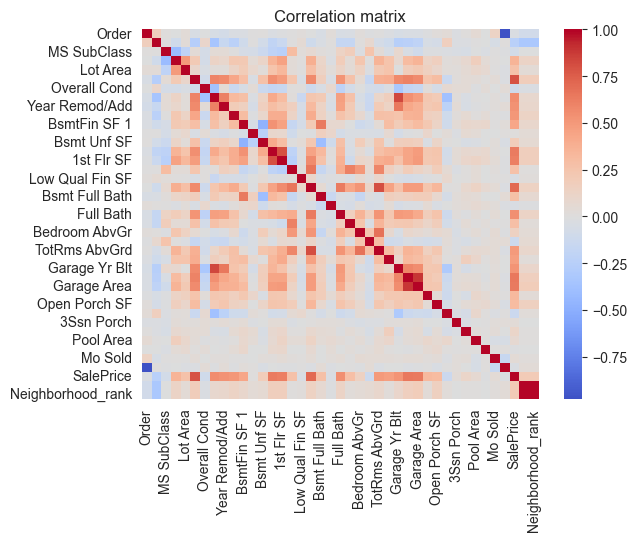

In [62]:
plt.figure()
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

# 8. Scatterplots — Always inspect visually

Correlation coefficients should **never be interpreted without visualization**.

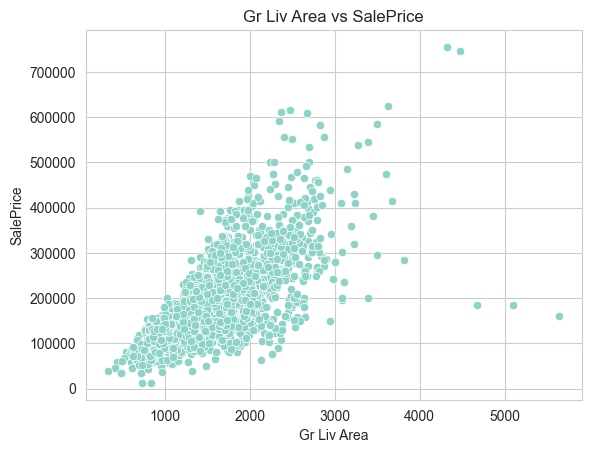

In [63]:
plt.figure()
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice')
plt.title("Gr Liv Area vs SalePrice")
plt.show()

Try other strong predictors.

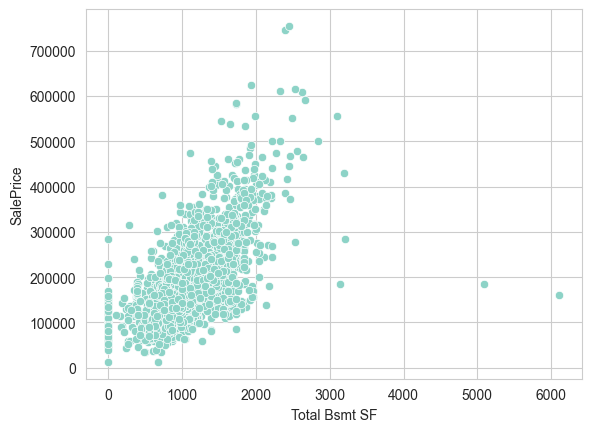

In [64]:
sns.scatterplot(data=df, x='Total Bsmt SF', y='SalePrice')
plt.show()

# 9. When Pearson Correlation Fails

Pearson measures **linear alignment**, not general relationships.

Example with synthetic nonlinear data.

In [66]:
x = np.linspace(-3,3,200)
y = x**2

round(np.corrcoef(x,y)[0,1])

0

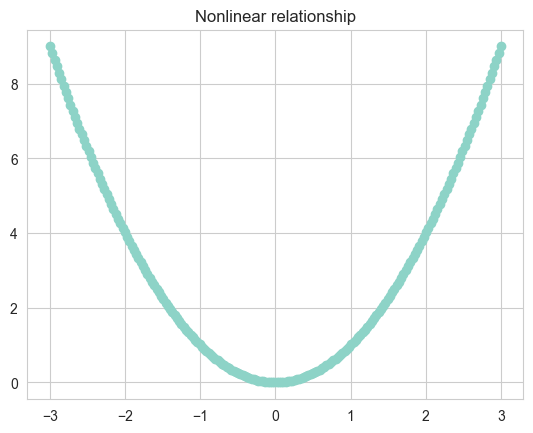

In [67]:
plt.figure()
plt.scatter(x,y)
plt.title("Nonlinear relationship")
plt.show()

# 10. Spearman Correlation

Spearman correlation works with **ranks** and captures monotonic relationships.

In [68]:
df.corr(method='spearman', numeric_only=True)['SalePrice'].sort_values(ascending=False).head(15)

SalePrice         1.000000
Overall Qual      0.808800
Gr Liv Area       0.723342
Garage Cars       0.701813
Year Built        0.680822
Garage Area       0.660676
Garage Yr Blt     0.637674
Full Bath         0.634161
Total Bsmt SF     0.606184
Year Remod/Add    0.601454
1st Flr SF        0.581536
Fireplaces        0.526137
TotRms AbvGrd     0.499253
Open Porch SF     0.479578
Mas Vnr Area      0.442471
Name: SalePrice, dtype: float64

# 11. Categorical → Numeric association

Example: `OverallQual` vs `SalePrice`.

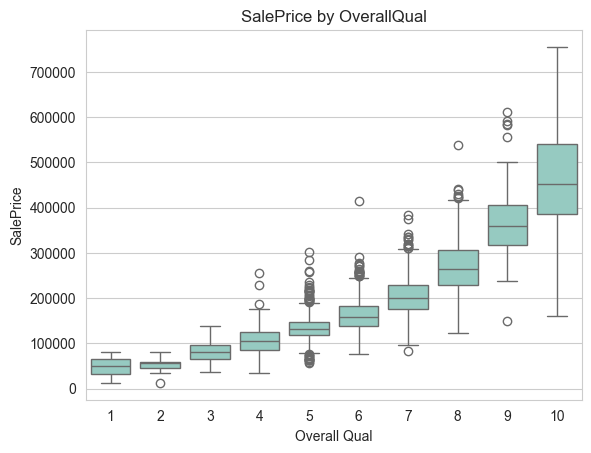

In [69]:
plt.figure()
sns.boxplot(data=df, x='Overall Qual', y='SalePrice')
plt.title("SalePrice by OverallQual")
plt.show()

# 12. Multicollinearity

Some predictors measure very similar concepts.

Example: `GarageCars` vs `GarageArea`.

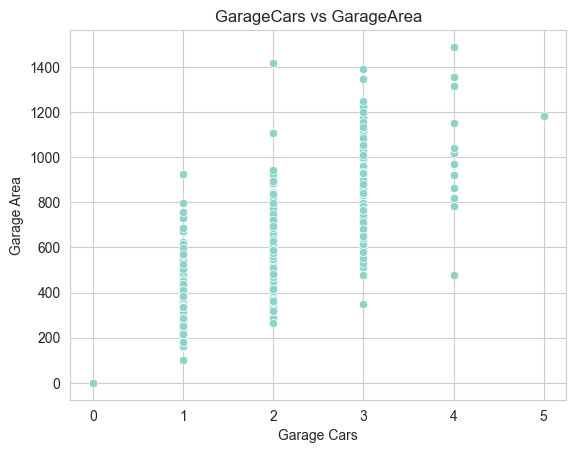

In [70]:
sns.scatterplot(data=df, x='Garage Cars', y='Garage Area')
plt.title("GarageCars vs GarageArea")
plt.show()

Highly correlated predictors may cause **unstable regression coefficients**.

# 13. Exercise

Perform a **target association audit**:

1. Identify the top 10 variables correlated with `SalePrice`
2. Plot 3 scatterplots with strong correlations
3. Plot 2 categorical predictors against `SalePrice`
4. Identify 3 potential multicollinearity risks

Add your findings to the report section:

`Variable associations`

# 14. Extras

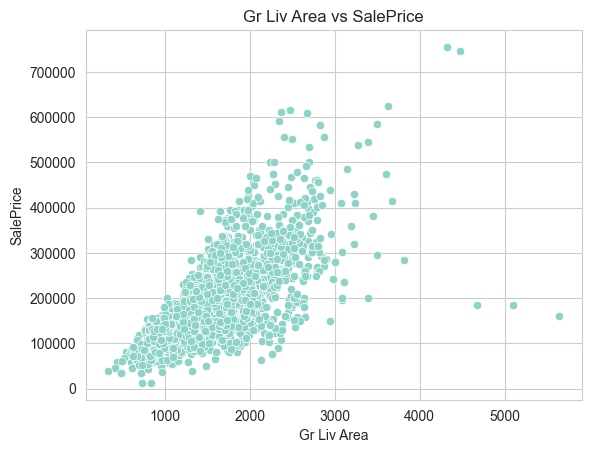

In [71]:
#corelation between SalePrice and Gr Liv Area
sns.scatterplot(data=df, x='Gr Liv Area', y='SalePrice')
plt.title("Gr Liv Area vs SalePrice")
plt.show()

In [72]:
#pearson correlation between SalePrice and Gr Liv Area
corr_pearson = df[['Gr Liv Area','SalePrice']].corr().iloc[0,1]
print(f"Pearson correlation: {corr_pearson:.2f}")

Pearson correlation: 0.71


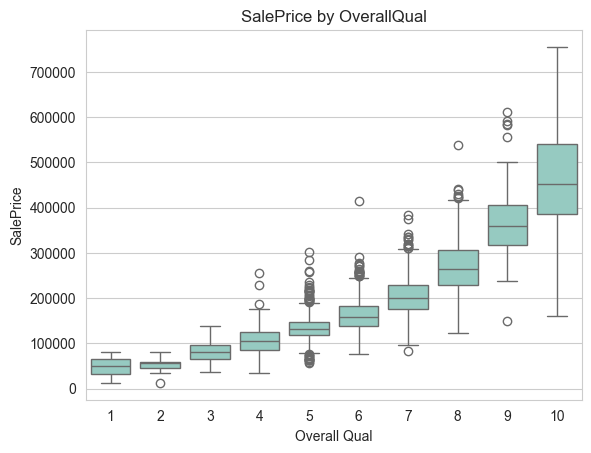

In [73]:
#correlation between SalePrice and Overall Qual
sns.boxplot(data=df, x='Overall Qual', y='SalePrice')
plt.title("SalePrice by OverallQual")
plt.show()

In [74]:
#calculate spearman correlation
corr_spearman = df[['Overall Qual','SalePrice']].corr(method='spearman').iloc[0,1]
print(f"Spearman correlation: {corr_spearman:.2f}")

Spearman correlation: 0.81


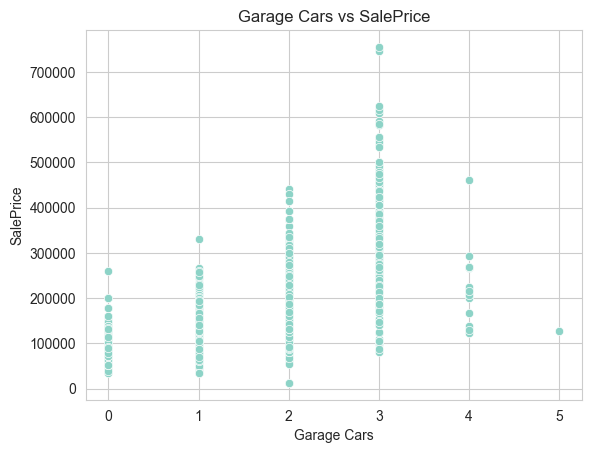

In [75]:
#correlation between Sale Price and Garage Cars
sns.scatterplot(data=df, x='Garage Cars', y='SalePrice')
plt.title("Garage Cars vs SalePrice")
plt.show()

In [76]:
#Pearson correlation between SalePrice and Garage Cars
corr_garage_cars = df[['Garage Cars','SalePrice']].corr().iloc[0,1]
print(f"Pearson correlation: {corr_garage_cars:.2f}")

Pearson correlation: 0.65


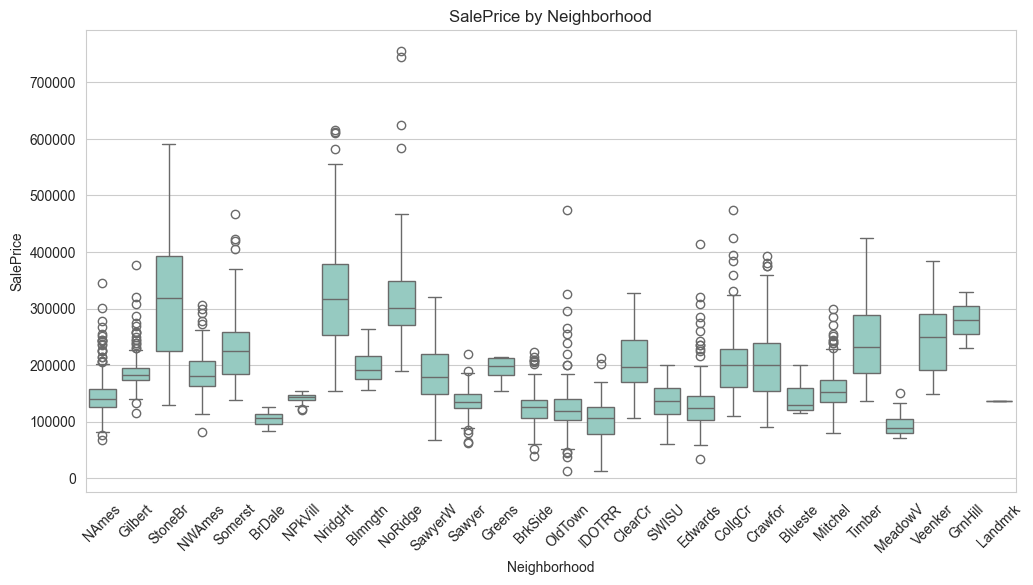

In [77]:
#correlation between Sale Price and Neighborhood
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Neighborhood', y='SalePrice')
plt.xticks(rotation=45)
plt.title("SalePrice by Neighborhood")
plt.show()

In [78]:
#calculate spearman correlation between SalePrice and Neighborhood
#First we need to convert the categorical variable 'Neighborhood' into numeric ranks
df['Neighborhood_rank'] = df['Neighborhood'].rank(method='dense')
corr_neighborhood = df[['Neighborhood_rank','SalePrice']].corr(method='spearman').iloc[0,1]
print(f"Spearman correlation: {corr_neighborhood:.2f}")

Spearman correlation: 0.17


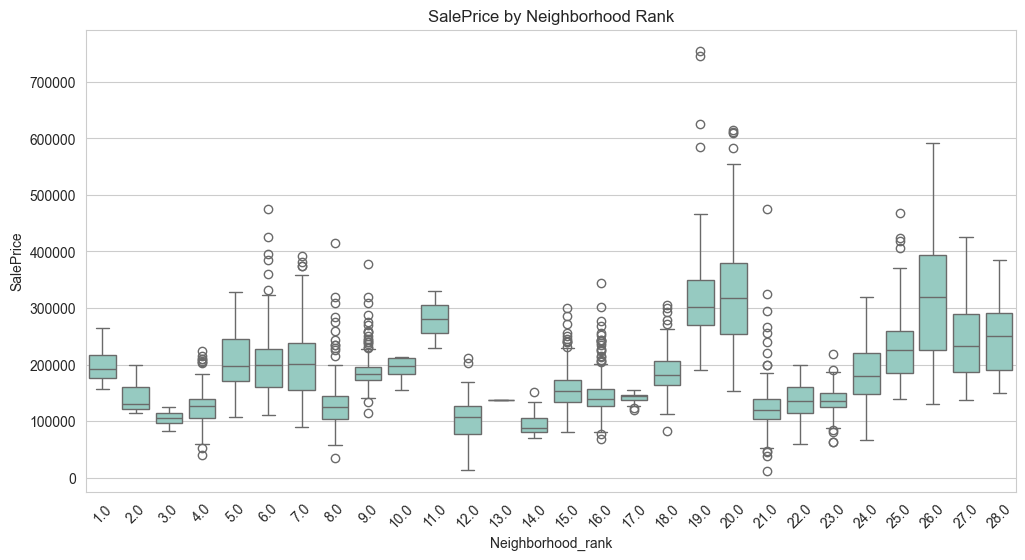

In [79]:
#print again se boxplot with number of neighborhoods not names
plt.figure(figsize=(12,6))
sns.boxplot(data=df, x='Neighborhood_rank', y='SalePrice')
plt.xticks(rotation=45)
plt.title("SalePrice by Neighborhood Rank")
plt.show()

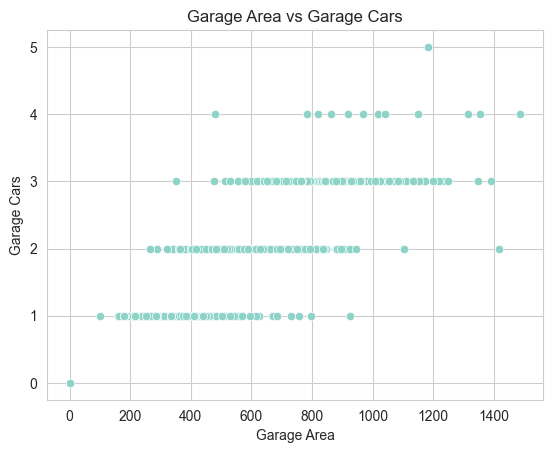

In [80]:
#correlation between Garage Area and Garage Cars
sns.scatterplot(data=df, x='Garage Area', y='Garage Cars')
plt.title("Garage Area vs Garage Cars")
plt.show()

In [81]:
#Pearson correlation between Garage Area and Garage Cars
corr_garage_area_cars = df[['Garage Area','Garage Cars']].corr().iloc[0,1]
print(f"Pearson correlation: {corr_garage_area_cars:.2f}")

Pearson correlation: 0.89


In [82]:
import pandas as pd
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

variables = ['Garage Cars', 'Garage Area', 'Gr Liv Area', 'Total Bsmt SF']

X = df[variables].dropna()

X = sm.add_constant(X)

vif = pd.DataFrame()
vif["variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
print(vif)

        variable        VIF
0          const  11.736549
1    Garage Cars   4.899938
2    Garage Area   5.092702
3    Gr Liv Area   1.443674
4  Total Bsmt SF   1.415570


In [83]:
#regressao linear com SalePrice como target e Garage Cars, Garage Area, Gr Liv Area e Total Bsmt SF como preditores
X = df[variables].dropna()
y = df.loc[X.index, 'SalePrice']

import statsmodels.api as sm
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.692
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     1645.
Date:                Mon, 16 Mar 2026   Prob (F-statistic):               0.00
Time:                        16:35:35   Log-Likelihood:                -35481.
No. Observations:                2928   AIC:                         7.097e+04
Df Residuals:                    2923   BIC:                         7.100e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -3.428e+04   2807.148    -12.212

In [84]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency

table = pd.crosstab(df["Garage Type"], df["House Style"])

chi2, p, dof, expected = chi2_contingency(table)

n = table.sum().sum()
k = min(table.shape)

cramers_v = np.sqrt(chi2 / (n * (k - 1)))

print(table)
print("p-value:", p)
print("Cramer's V:", cramers_v)

House Style  1.5Fin  1.5Unf  1Story  2.5Fin  2.5Unf  2Story  SFoyer  SLvl
Garage Type                                                              
2Types            1       0      14       0       0       6       1     1
Attchd           68       3    1055       1       2     494      35    73
Basment           4       0      11       1       0       3       8     9
BuiltIn           7       0       2       0       0     143       4    30
CarPort           1       0       9       0       0       4       1     0
Detchd          203      12     316       4      20     191      21    15
p-value: 6.1966826922941524e-145
Cramer's V: 0.2398528113212721
